In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import joblib

In [2]:
X_train = pd.read_csv('../data/X_smote.csv')
y_train = pd.read_csv('../data/y_smote.csv')

X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv')

In [3]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [5]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]

In [6]:
print(
    "Accuracy:",
    accuracy_score(y_test,y_pred)
)

print(
    "Precision:",
    precision_score(y_test,y_pred)
)

print(
    "Recall:",
    recall_score(y_test,y_pred)
)

print(
    "F1:",
    f1_score(y_test,y_pred)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test,y_prob)
)

Accuracy: 0.8061224489795918
Precision: 0.375
Recall: 0.3191489361702128
F1: 0.3448275862068966
ROC AUC: 0.7533809975019381


In [7]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.90      0.89       247
           1       0.38      0.32      0.34        47

    accuracy                           0.81       294
   macro avg       0.62      0.61      0.62       294
weighted avg       0.79      0.81      0.80       294



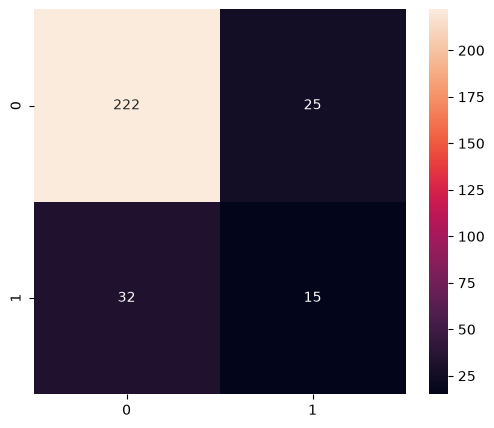

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

In [9]:
importance = pd.DataFrame({
    'Feature':X_train.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
22,StockOptionLevel,0.081462
32,FinancialLoss,0.055149
13,JobSatisfaction,0.053419
31,ReplacementDifficulty,0.048803
30,EmployeeValueScore,0.047918
7,EnvironmentSatisfaction,0.046316
25,WorkLifeBalance,0.045144
11,JobLevel,0.041195
15,MonthlyIncome,0.040430
1,BusinessTravel,0.037058


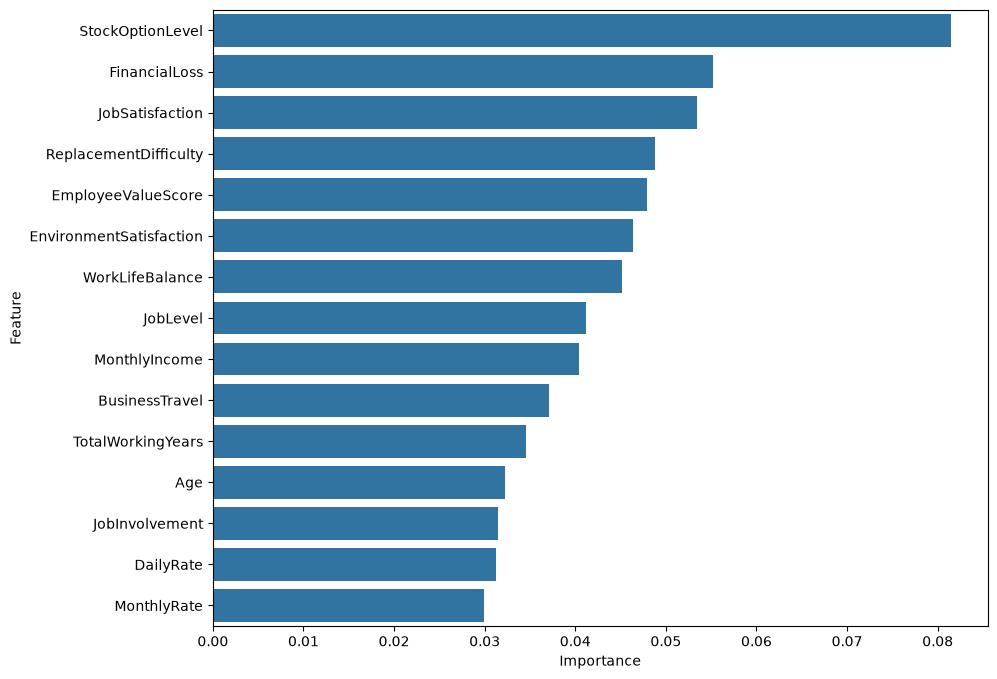

In [10]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.show()

In [11]:
joblib.dump(
    rf,
    '../models/random_forest.pkl'
)

['../models/random_forest.pkl']